In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.dimensionality import BaseDimensionalityReduction
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
import torch
from wordcloud import WordCloud

In [22]:
indo_stopwords = [
    # Basic Indonesian stopwords (keep these)
    "yang", "dan", "di", "dengan", "untuk", "dari", "ke", "pada", "ini", "itu",
    "atau", "ada", "juga", "dalam", "saya", "kamu", "anda", "mereka", "kita", "kami",
    "dia", "nya", "adalah", "akan", "oleh", "seperti", "telah", "sudah", "bisa", "dapat",
    "tidak", "tak", "jangan", "ya", "via", "yg", "dgn", "utk", "dr", "pd", "dlm", "sdh", "tdk",
    "tapi", "aku","gini","begini", "kayak", "gaspoll", "gaspol"
    
    # All candidate names and variations (since they appear everywhere)
    "anies", "baswedan", "rasyid", "muhaimin", "iskandar", "cak", "imin", "gus", 
    "prabowo", "subianto", "gibran", "rakabuming", "raka", "ganjar", "pranowo", 
    "mahfud", "md", "gama", "mawi", "abdurrahman", "abdul", "amin"
    
    # Titles and name prefixes
    "mas", "pak", "bu", "bapak", "ibu", "om", "tante", "mbak", "bro", "sis", "bang", 
    "abang", "kak", "adek", "adik", "kakak", "bung", "prof", "dr", "haji", "hajah", "h",
    
    # Social media expressions
    "rt", "dm", "pm", "cc", "wkwk", "haha", "woi", "hey", "ah", "eh", "oh", "hmm", "btw",
    "omg", "lol", "sih", "aja", "gitu", "banget", "kok", "deh", "ih", "yuk", "mantap",
    "insya", "insyaallah", "alhamdulillah", "bismillah", "amin", "allahuma", "allah",
    
    # Locations
    "jakarta", "jawa", "barat", "timur", "tengah", "utara", "selatan", "sumatra", "bali", 
    "aceh", "kota", "desa", "daerah", "wilayah", "provinsi", "kabupaten", "kawasan",
    "bandung", "surabaya", "makassar", "balikpapan", "semarang", "yogyakarta", "solo", "korea"
    
]

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [24]:
def run_topic_modeling(df, group_name='ALL'):
     # Set up custom vectorizer
    vectorizer = CountVectorizer(
        stop_words=indo_stopwords,
        ngram_range=(1, 3),
        min_df=5,
        max_df=0.7
    )

    # Set up UMAP
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )

    # Set up HDBSCAN
    hdbscan_model = HDBSCAN(
        min_cluster_size=10,
        min_samples=5,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    # Set up c-TF-IDF
    ctfidf_model = ClassTfidfTransformer(
        reduce_frequent_words=True,
        bm25_weighting=True
    )

    # Sentence embeddings
    embedding_model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

    # BERTopic setup
    topic_model = BERTopic(
        language="multilingual",
        calculate_probabilities=True,
        verbose=True,
        nr_topics=15,
        min_topic_size=5,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        ctfidf_model=ctfidf_model,
        vectorizer_model=vectorizer,
        embedding_model=embedding_model
    )

    # Fit model
    docs = df['full_text'].tolist()
    topics, probs = topic_model.fit_transform(docs)
    
    # Generate custom topic labels
    topic_labels = {}
    for topic_id in topic_model.get_topic_info()["Topic"]:
        if topic_id == -1:
            topic_labels[topic_id] = "outlier"
            continue
        words = [word for word, _ in topic_model.get_topic(topic_id)[:5]]
        if any(term in words for term in ["bal", "bali", "rahajeng", "rawuh"]):
            topic_labels[topic_id] = "Kampanye Bali"
        elif any(term in words for term in ["jawa", "tengah", "jateng", "banteng"]):
            topic_labels[topic_id] = "Basis Dukungan Jawa Tengah"
        elif any(term in words for term in ["legislatif", "eksekutif", "yudikatif", "jejak", "rekam"]):
            topic_labels[topic_id] = "Pengalaman Pemerintahan"
        elif any(term in words for term in ["fokus", "dukung", "motivasi", "kembang"]):
            topic_labels[topic_id] = "Dukungan & Motivasi"
        elif any(term in words for term in ["demokrasi", "partai", "pdip", "banteng", "merah"]):
            topic_labels[topic_id] = "Dukungan Partai PDI-P"
        elif any(term in words for term in ["dame", "hati", "adem", "damai", "sejuk"]):
            topic_labels[topic_id] = "Citra Kepemimpinan Adem"
        elif any(term in words for term in ["aspirasi", "dengar", "blusuk", "jumpa"]):
            topic_labels[topic_id] = "Pendekatan ke Masyarakat"
        elif any(term in words for term in ["tegak", "lurus", "jujur", "bersih"]):
            topic_labels[topic_id] = "Integritas & Kejujuran"
        elif any(term in words for term in ["huru", "hara", "politik", "sembuh", "luka"]):
            topic_labels[topic_id] = "Perbaikan Situasi Politik"
        elif any(term in words for term in ["penjuru", "nusantara", "kenal"]):
            topic_labels[topic_id] = "Popularitas Nasional"
        else:
            # Use the first few words as a generic label
            topic_labels[topic_id] = " & ".join(words[:3])
    topic_model.set_topic_labels(topic_labels)

    # Topic info
    topic_info = topic_model.get_topic_info()
    print(f"\nTopic Information for: {group_name}")
    print(topic_info.head(10))

    # Print topic summaries
    print(f"\nTopik Pembicaraan Masyarakat terhadap Calon Ganjar-Mahfud ({group_name}):")
    for index, row in topic_info.iterrows():
        if row["Topic"] != -1:
            topic_id = row["Topic"]
            words = [word[0] for word in topic_model.get_topic(topic_id)[:8]]
            print(f"Theme: {row['Name']}")
            print(f"Keywords: {', '.join(words)}")
            print(f"Document count: {row['Count']}")
            print("-" * 50)

    # Bar chart of topic distribution
    plt.figure(figsize=(12, 6))
    topic_counts = topic_info[topic_info["Topic"] != -1]["Count"]
    topic_names = [topic_labels[topic] for topic in topic_info[topic_info["Topic"] != -1]["Topic"]]

    bars = plt.bar(topic_names, topic_counts, color=plt.cm.viridis(np.linspace(0, 1, len(topic_counts))))
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    plt.xticks(rotation=45, ha="right")
    plt.title(f"Distribusi Topik: {group_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Topik Pembicaraan", fontsize=12)
    plt.ylabel("Jumlah Tweet", fontsize=12)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Interactive Visualizations
    display(topic_model.visualize_topics())
    display(topic_model.visualize_hierarchy())
    display(topic_model.visualize_heatmap())

    # Word Clouds for top 3 topics
    plt.figure(figsize=(15, 10))
    for i, topic_id in enumerate(topic_info[topic_info['Topic'] != -1]['Topic'][:3]):
        plt.subplot(1, 3, i+1)
        words = dict(topic_model.get_topic(topic_id)[:15])
        wordcloud = WordCloud(width=400, height=400, background_color='white',
                              colormap='viridis', max_words=50).generate_from_frequencies(words)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"Topic: {topic_labels[topic_id]}", fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Representative sentences per topic
    print(f"\nKalimat Representatif untuk Setiap Topik ({group_name}):")
    rep_docs = topic_model.get_representative_docs()
    rows = []
    for topic_id, texts in rep_docs.items():
        if topic_id == -1:
            continue
        rows.append({
            "Topic ID": topic_id,
            "Label": topic_labels[topic_id],
            "Representative Sentence": texts[0]  # You can use texts[:3] for more
        })
    rep_df = pd.DataFrame(rows)
    display(rep_df)

    return topic_model, topics, probs

In [25]:
df_03 = pd.read_csv('data/03_full_context_pred.csv')

2025-05-26 21:55:35,183 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 1183/1183 [09:37<00:00,  2.05it/s]
2025-05-26 22:05:13,503 - BERTopic - Embedding - Completed ✓
2025-05-26 22:05:13,504 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 22:05:42,990 - BERTopic - Dimensionality - Completed ✓
2025-05-26 22:05:42,991 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 22:27:17,021 - BERTopic - Cluster - Completed ✓
2025-05-26 22:27:17,023 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 22:27:19,089 - BERTopic - Representation - Completed ✓
2025-05-26 22:27:19,090 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 22:27:19,133 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 22:27:20,496 - BERTopic - Representation - Completed ✓
2025-05-26 22:27:20,502 - BERTopic - Topic reduction - 


Topic Information for: POSITIVE
   Topic  Count                                               Name  \
0     -1  13262                       -1_pilih_03_presiden_menjadi   
1      0  17409                      0_luar_biasa_luar biasa_orang   
2      1   2141                             1_all in_all_in_gaspol   
3      2   1850                         2_tiga_paslon_03_paslon 03   
4      3   1162      3_positif_perubahan positif_ekonomi_perubahan   
5      4    899      4_program_unggulan_bermanfaat_melalui program   
6      5    697                      5_03_pilih 03_dukung 03_in 03   
7      6    129  6_investasi_transparansi_pasti lebih baik_past...   
8      7    112  7_disabilitas_penyandang disabilitas_penyandan...   
9      8     92                    8_era_gratis_perkembangan_dunia   

                                          CustomName  \
0                                            outlier   
1                          luar & biasa & luar biasa   
2                           

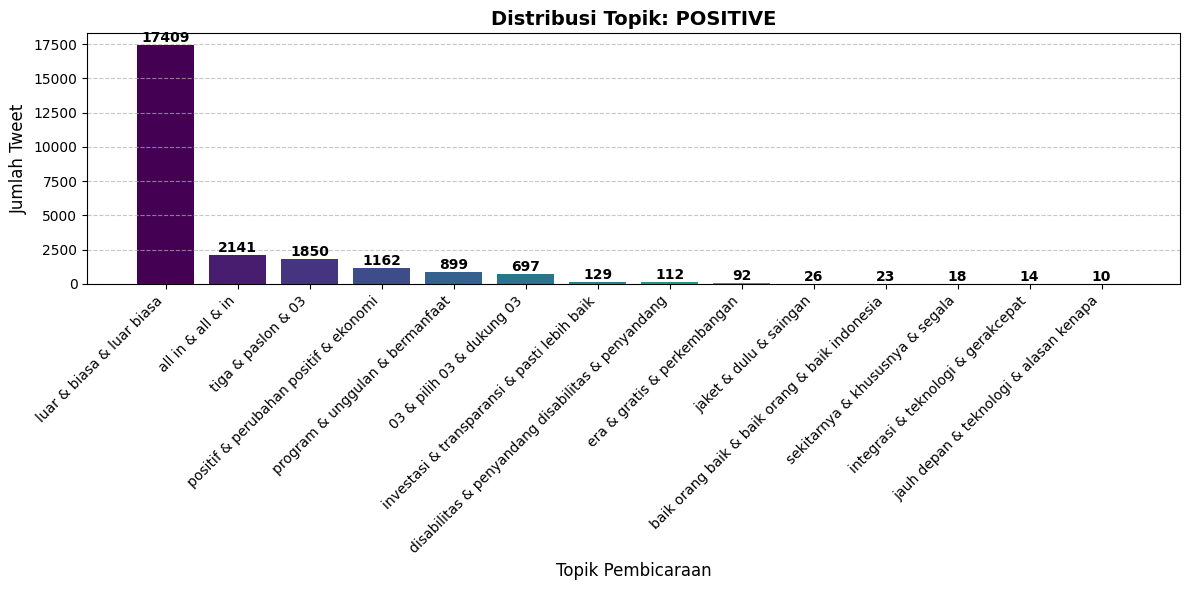

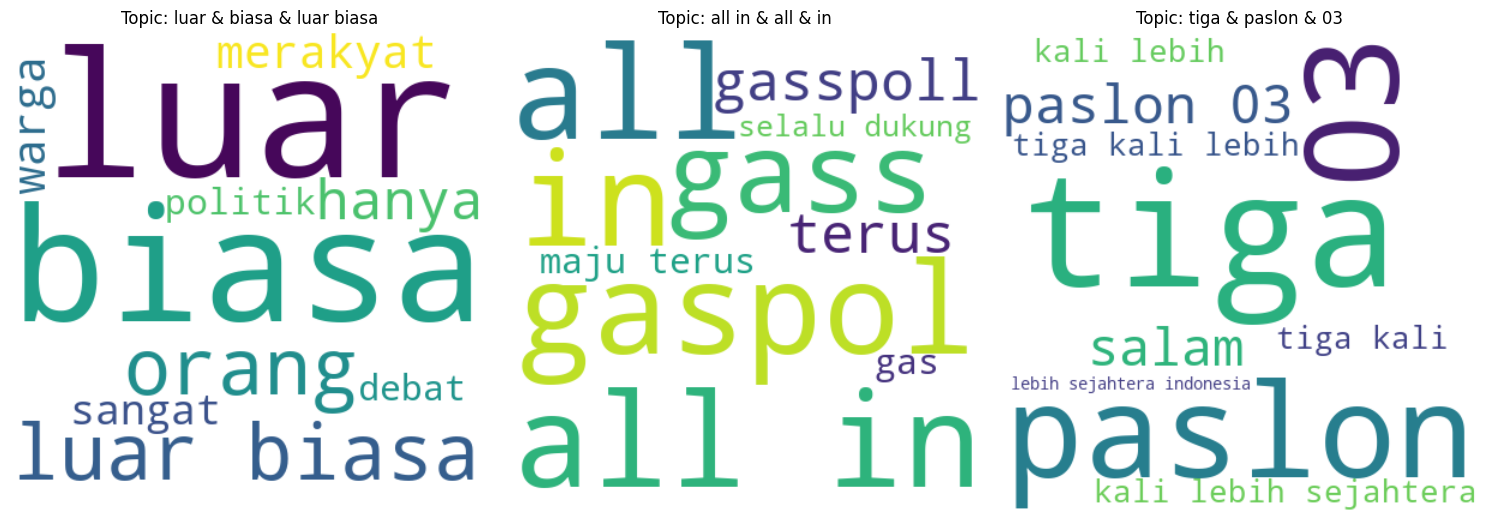


Kalimat Representatif untuk Setiap Topik (POSITIVE):


,Topic ID,Label,Representative Sentence
0,0,luar & biasa & luar biasa,pilih pak ganjar pak mahfud untuk indonesia ya...
1,1,all in & all & in,all in pak ganjar
2,2,tiga & paslon & 03,slank dan paslon 03 keren banget di gbk tiga k...
3,3,positif & perubahan positif & ekonomi,ganjar pranowo mahfud md semakin dilihat sebag...
4,4,program & unggulan & bermanfaat,sungguh rencana kebijakan pak ganjar sangat ba...
5,5,03 & pilih 03 & dukung 03,makin yakin pilih 03
6,6,investasi & transparansi & pasti lebih baik,pak mahfud bukan hanya berkomitmen untuk membe...
7,7,disabilitas & penyandang disabilitas & penyandang,ganjar pranowo dan mahfud md menegaskan komitm...
8,8,era & gratis & perkembangan,internet gratis ganjar di era digitalisasi ini...
9,9,jaket & dulu & saingan,ganjar cakep an sekarang saingan sama mas alam...


(<bertopic._bertopic.BERTopic at 0x1d5884397c0>,
 [0,
  -1,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  -1,
  -1,
  1,
  0,
  4,
  -1,
  0,
  -1,
  -1,
  0,
  -1,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  -1,
  0,
  -1,
  0,
  -1,
  -1,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  -1,
  0,
  -1,
  -1,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  -1,
  -1,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  -1,
  -1,
  -1,
  0,
  0,
  -1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  -1,
  -1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  -1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  -1,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  0,
  -1,
  0,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  0,
  0,
  -1,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  -1,
  0,
  0,
  -1,
  0,
  0,
  -1,
  0,
  -1,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  0,
  -1,
  0,
  0,
  1,
  0,
  -1,
  -

In [26]:
df_positive = df_03[df_03['predicted_label'] == 'POSITIVE']
run_topic_modeling(df_positive, group_name='POSITIVE')

2025-05-26 22:27:26,277 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 350/350 [03:36<00:00,  1.62it/s]
2025-05-26 22:31:02,924 - BERTopic - Embedding - Completed ✓
2025-05-26 22:31:02,925 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 22:31:10,390 - BERTopic - Dimensionality - Completed ✓
2025-05-26 22:31:10,392 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 22:31:29,183 - BERTopic - Cluster - Completed ✓
2025-05-26 22:31:29,184 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 22:31:30,033 - BERTopic - Representation - Completed ✓
2025-05-26 22:31:30,034 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 22:31:30,049 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 22:31:30,788 - BERTopic - Representation - Completed ✓
2025-05-26 22:31:30,791 - BERTopic - Topic reduction - Re


Topic Information for: NEGATIVE
   Topic  Count                                     Name  \
0     -1   3938           -1_pendukung 03_milih_jd_salah   
1      0   3399             0_indonesia_baliho_lain_suka   
2      1   1910  1_pendukung 03_pilih 03_buzzer 03_suara   
3      2   1296              2_presiden_debat_dinasti_jd   
4      3    133              3_survey_hasil_exit_lembaga   
5      4    128          4_kemiskinan_berjalan_gaji_jual   
6      5     77                 5_berita_baca_dibaca_kau   
7      6     68        6_strategi_proyek_posisi_nasional   
8      7     67    7_belimbing sayur_belimbing_gua_sayur   
9      8     43                   8_fokus_dehh_nihh_ciri   

                            CustomName  \
0                              outlier   
1            indonesia & baliho & lain   
2  pendukung 03 & pilih 03 & buzzer 03   
3           presiden & debat & dinasti   
4                survey & hasil & exit   
5         kemiskinan & berjalan & gaji   
6           

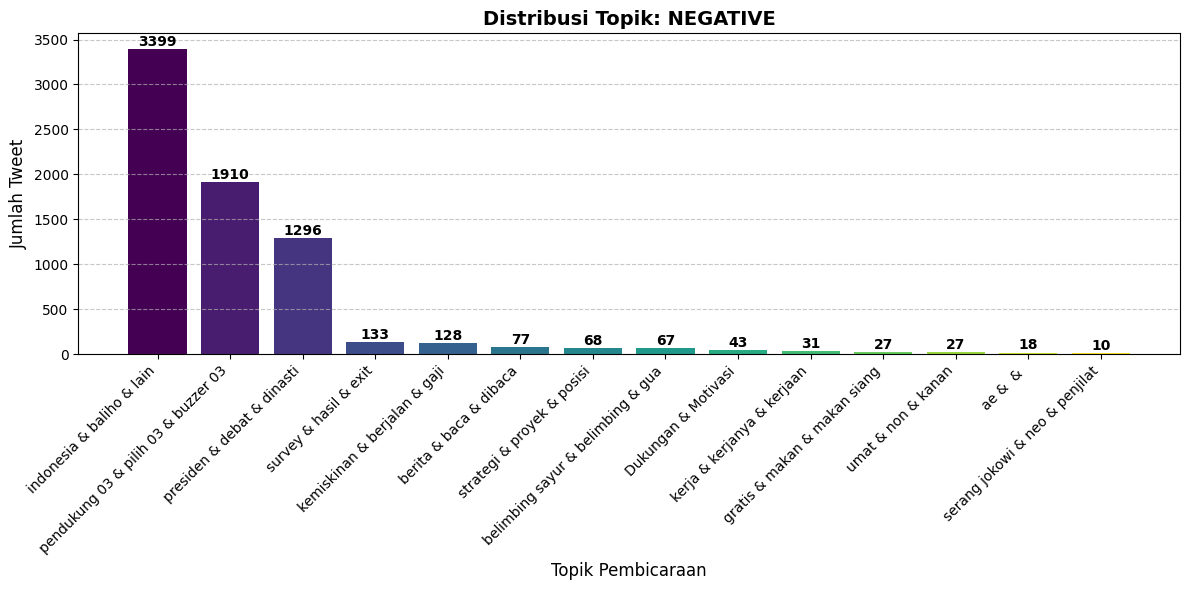

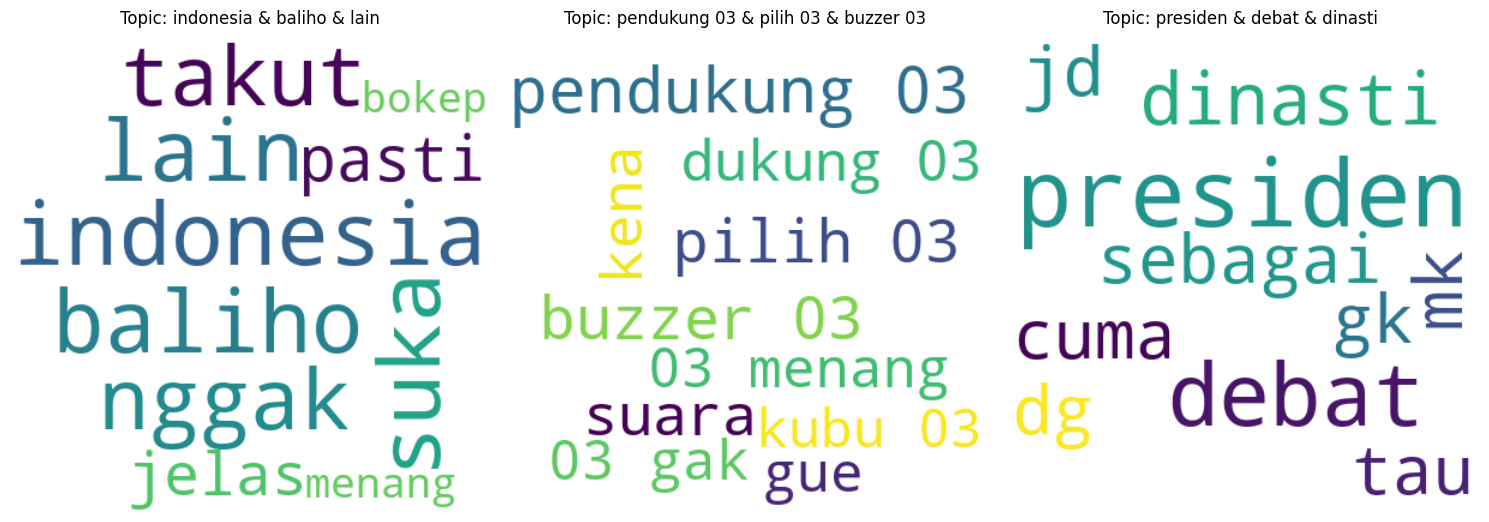


Kalimat Representatif untuk Setiap Topik (NEGATIVE):


,Topic ID,Label,Representative Sentence
0,0,indonesia & baliho & lain,anjiir bener kata temen gw teamnya ganjar itu ...
1,1,pendukung 03 & pilih 03 & buzzer 03,akhirnya pendukung 03 muncul juga wkkw jujur g...
2,2,presiden & debat & dinasti,dari sebelum debat sudah ketahuan anies pasti ...
3,3,survey & hasil & exit,jgn bikin mega cs halu dgn survey tolol kek gi...
4,4,kemiskinan & berjalan & gaji,solusi bodoh dr pemimpin yang males mikir ya g...
5,5,berita & baca & dibaca,dia ini buzzer 03 geblek jadi lu jangan percay...
6,6,strategi & proyek & posisi,anies serang ikn jkw pasang strategi tiba2 gan...
7,7,belimbing sayur & belimbing & gua,anda sadis bro kasihan buzzer pak ganjar malam...
8,8,Dukungan & Motivasi,gaa ngerti lagi lahh klo aku udah fokus ke gan...
9,9,kerja & kerjanya & kerjaan,kerjaan lu ghibah aama nyinyir jokowi prabowo ...


(<bertopic._bertopic.BERTopic at 0x1d58a8a8590>,
 [-1,
  0,
  -1,
  0,
  0,
  0,
  2,
  -1,
  0,
  -1,
  -1,
  0,
  -1,
  2,
  2,
  -1,
  0,
  -1,
  -1,
  2,
  0,
  0,
  -1,
  -1,
  2,
  -1,
  0,
  -1,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  3,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  3,
  -1,
  2,
  -1,
  0,
  -1,
  5,
  -1,
  0,
  -1,
  -1,
  -1,
  0,
  2,
  -1,
  -1,
  -1,
  -1,
  0,
  0,
  0,
  -1,
  0,
  2,
  2,
  0,
  -1,
  8,
  0,
  0,
  0,
  8,
  -1,
  -1,
  0,
  0,
  0,
  -1,
  -1,
  0,
  -1,
  0,
  -1,
  -1,
  2,
  2,
  -1,
  0,
  0,
  -1,
  0,
  2,
  9,
  -1,
  0,
  2,
  -1,
  -1,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  -1,
  -1,
  0,
  0,
  -1,
  0,
  2,
  0,
  -1,
  3,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  -1,
  2,
  -1,
  2,
  0,
  -1,
  -1,
  0,
  0,
  0,
  -1,
  -1,
  0,
  6,
  -1,
  0,
  -1,
  0,
  2,
  2,
  0,
  0,
  -1,
  -1,
  2,
  0,
  0,
  0,
  0,
  -1,
  0,
  2,
  -1,
  11,
  0,
  -1,
  2,
  -1,
  2,
  -1,
 

In [27]:
df_negative = df_03[df_03['predicted_label'] == 'NEGATIVE']
run_topic_modeling(df_negative, group_name='NEGATIVE')

2025-05-26 22:31:37,098 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 295/295 [02:01<00:00,  2.43it/s]
2025-05-26 22:33:38,842 - BERTopic - Embedding - Completed ✓
2025-05-26 22:33:38,842 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-26 22:33:51,908 - BERTopic - Dimensionality - Completed ✓
2025-05-26 22:33:51,909 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 22:34:20,187 - BERTopic - Cluster - Completed ✓
2025-05-26 22:34:20,188 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-26 22:34:20,574 - BERTopic - Representation - Completed ✓
2025-05-26 22:34:20,575 - BERTopic - Topic reduction - Reducing number of topics
2025-05-26 22:34:20,587 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 22:34:20,855 - BERTopic - Representation - Completed ✓
2025-05-26 22:34:20,857 - BERTopic - Topic reduction - Re


Topic Information for: NEUTRAL
   Topic  Count                                            Name  \
0     -1   2529                   -1_paslon_anies_paslon 03_apa   
1      0   4230                   0_harapan_bersama_set_sat set   
2      1   1263               1_paslon 03_paslon_pilih 03_salam   
3      2    591                    2_politik_calon_presiden_the   
4      3    272                  3_program_gratis_digital_akses   
5      4    165                    4_debat_juara_hebat_cawapres   
6      5    119                        5_all in_all_in_milenial   
7      6     93                   6_bela_menolak_tegas_pengamat   
8      7     46              7_strategi_strategis_ekonomi_massa   
9      8     34  8_pasti lebih baik_pasti lebih_mendorong_juara   

                                   CustomName  \
0                                     outlier   
1                     harapan & bersama & set   
2               paslon 03 & paslon & pilih 03   
3                   Perbaikan Situ

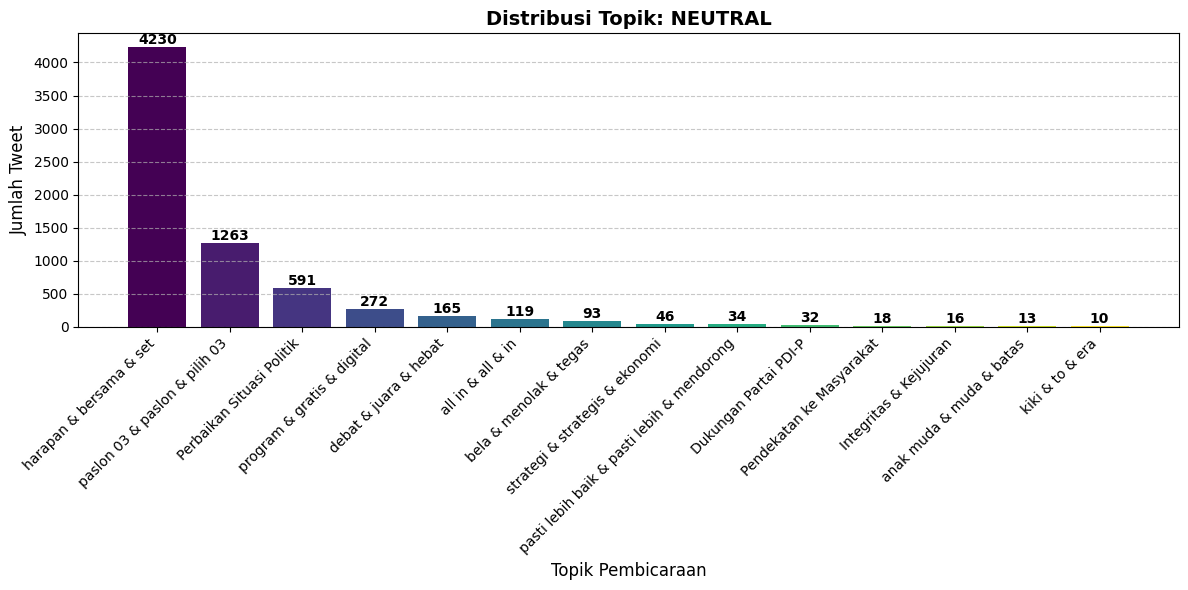

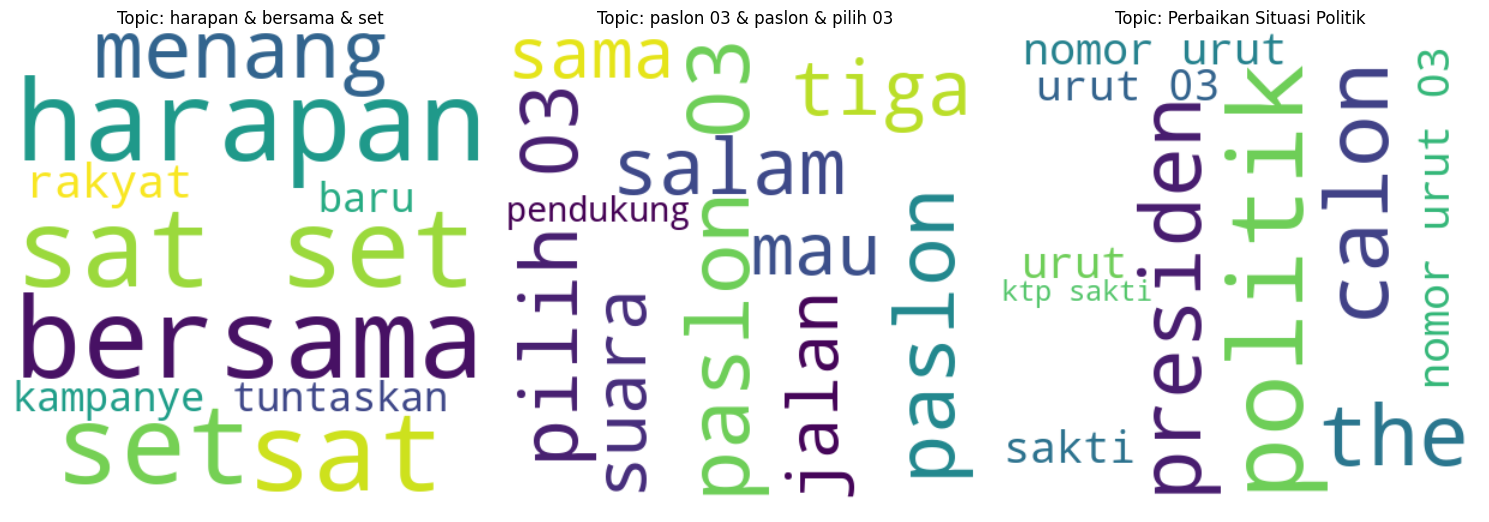


Kalimat Representatif untuk Setiap Topik (NEUTRAL):


,Topic ID,Label,Representative Sentence
0,0,harapan & bersama & set,ganjar mahfud akan menjaga stabilitas ekonomi ...
1,1,paslon 03 & paslon & pilih 03,salam tiga jari salam kemenangan pasangan ganj...
2,2,Perbaikan Situasi Politik,calon wakil presiden cawapres nomor urut 03 ma...
3,3,program & gratis & digital,ganjar program ini memberikan solusi konkret t...
4,4,debat & juara & hebat,hemat biaya pilpres hebat ganjar mahfud juara ...
5,5,all in & all & in,all in ganjar
6,6,bela & menolak & tegas,pengamat sebut ganjar capres paling tegas bela...
7,7,strategi & strategis & ekonomi,wadas adalah proyek strategis nasional psn yan...
8,8,pasti lebih baik & pasti lebih & mendorong,ganjar mahfud memprioritaskan peningkatan infr...
9,9,Dukungan Partai PDI-P,ganjar prabowo yes ganjar yes anis no pdip no


(<bertopic._bertopic.BERTopic at 0x1d67e307d70>,
 [-1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  5,
  -1,
  0,
  -1,
  6,
  2,
  0,
  4,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  5,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  0,
  0,
  0,
  11,
  0,
  0,
  0,
  -1,
  -1,
  -1,
  0,
  0,
  0,
  -1,
  0,
  0,
  0,
  9,
  9,
  0,
  9,
  0,
  0,
  -1,
  -1,
  9,
  0,
  -1,
  -1,
  9,
  9,
  0,
  -1,
  -1,
  9,
  9,
  0,
  0,
  -1,
  0,
  0,
  -1,
  -1,
  0,
  0,
  0,
  -1,
  0,
  -1,
  5,
  5,
  0,
  0,
  5,
  9,
  9,
  0,
  2,
  0,
  0,
  0,
  -1,
  0,
  -1,
  0,
  2,
  0,
  0,
  0,
  0,
  -1,
  2,
  0,
  0,
  -1,
  0,
  0,
  -1,
  2,
  0,
  -1,
  -1,
  -1,
  9,
  9,
  9,
  9,
  -1,
  0,
  9,
  9,
  9,
  9,
  0,
  9,
  9,
  9,
  9,
  -1,
  0,
  9,
  2,
  0,
  3,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  -1,
  0,
  9,
  5,
  9,
  9,
  0,
  0,
  9,
  9,
  9,
  0,
  5,
  9,
  9,
  3,
  -1,
  0,
  0,
  3,
  -1,
  -1,
  -1,
  -1,
  0,
  -1,
  3,
  0,
  -1,
  

In [28]:
df_neutral = df_03[df_03['predicted_label'] == 'NEUTRAL']
run_topic_modeling(df_neutral, group_name='NEUTRAL')